In [1]:
# %%
# ============================================================
# 1. Physics Defined & Imports
# ============================================================

"""
Physics-Informed Neural Network: Nonlinear Schrödinger Equation

Governing Equation:       ih_t + (1/2)h_xx + |h|²h = 0
                          x ∈ [-5, 5], t ∈ [0, π/2]

where h(x,t) = u(x,t) + iv(x,t) is complex-valued

This splits into two coupled PDEs:
  Real part:      -v_t + (1/2)u_xx + (u² + v²)u = 0
  Imaginary part:  u_t + (1/2)v_xx + (u² + v²)v = 0

Boundary Conditions (Periodic):
  h(t, -5) = h(t, 5)
  h_x(t, -5) = h_x(t, 5)

Which translates to:
  u(t, -5) = u(t, 5)    and    v(t, -5) = v(t, 5)
  u_x(t, -5) = u_x(t, 5) and   v_x(t, -5) = v_x(t, 5)

Initial Condition:        h(0, x) = 2·sech(x)
  Real part:              u(0, x) = 2·sech(x)
  Imaginary part:         v(0, x) = 0
"""

import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
import torch
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


In [2]:
# %%
# ============================================================
# 2. SETUP
# ============================================================
dde.config.set_default_float("float64")
print(f"Backend: {dde.backend.backend_name}")

# Domain parameters
x_min, x_max = -5.0, 5.0
t_min, t_max = 0.0, np.pi/2

print("\n" + "="*70)
print("📊 NONLINEAR SCHRÖDINGER EQUATION - PINN SETUP")
print("="*70)
print(f"Governing Equation: ih_t + (1/2)h_xx + |h|²h = 0")
print(f"\nCoupled Real-Imaginary System:")
print(f"  Real:      -v_t + (1/2)u_xx + (u² + v²)u = 0")
print(f"  Imaginary:  u_t + (1/2)v_xx + (u² + v²)v = 0")
print(f"\nDomain: x ∈ [{x_min}, {x_max}], t ∈ [0, {t_max:.4f}]")
print(f"Boundary Conditions: Periodic at x = ±5")
print(f"Initial Condition: h(0,x) = 2·sech(x)")
print("="*70)

Set the default float type to float64
Backend: pytorch

📊 NONLINEAR SCHRÖDINGER EQUATION - PINN SETUP
Governing Equation: ih_t + (1/2)h_xx + |h|²h = 0

Coupled Real-Imaginary System:
  Real:      -v_t + (1/2)u_xx + (u² + v²)u = 0
  Imaginary:  u_t + (1/2)v_xx + (u² + v²)v = 0

Domain: x ∈ [-5.0, 5.0], t ∈ [0, 1.5708]
Boundary Conditions: Periodic at x = ±5
Initial Condition: h(0,x) = 2·sech(x)


In [3]:
# %%
# ============================================================
# 3. DEFINE PROBLEM DOMAIN
# ============================================================

# Spatial domain
geom = dde.geometry.Interval(x_min, x_max)

# Temporal domain
timedomain = dde.geometry.TimeDomain(t_min, t_max)

# Combined space-time domain
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

In [4]:
# %%
# ============================================================
# 4. DEFINE COUPLED PDEs (CORRECTED)
# ============================================================

def pde_system(x, y):
    """
    Coupled PDEs from the Nonlinear Schrödinger equation
    
    CRITICAL: Correct formulation from the problem statement
    
    x[:, 0] = spatial coordinate (x)
    x[:, 1] = temporal coordinate (t)
    y[:, 0] = real part u(x,t)
    y[:, 1] = imaginary part v(x,t)
    
    Returns list of residuals:
        - residual_real: -v_t + (1/2)u_xx + (u² + v²)u = 0
        - residual_imag:  u_t + (1/2)v_xx + (u² + v²)v = 0
    """
    # Extract real and imaginary parts
    u = y[:, 0:1]
    v = y[:, 1:2]
    
    # First derivatives
    # i=0 means derivative of first output (u)
    # i=1 means derivative of second output (v)
    # j=0 means derivative w.r.t. first input (x)
    # j=1 means derivative w.r.t. second input (t)
    
    u_t = dde.grad.jacobian(y, x, i=0, j=1)  # ∂u/∂t
    v_t = dde.grad.jacobian(y, x, i=1, j=1)  # ∂v/∂t
    
    # Second spatial derivatives
    u_xx = dde.grad.hessian(y, x, component=0, i=0, j=0)  # ∂²u/∂x²
    v_xx = dde.grad.hessian(y, x, component=1, i=0, j=0)  # ∂²v/∂x²
    
    # Nonlinear term: |h|² = u² + v²
    h_squared = u**2 + v**2
    
    # CORRECTED EQUATIONS (matching the problem statement):
    
    # Real part equation: -v_t + (1/2)u_xx + (u² + v²)u = 0
    residual_real = -v_t + 0.5 * u_xx + h_squared * u
    
    # Imaginary part equation: u_t + (1/2)v_xx + (u² + v²)v = 0
    residual_imag = u_t + 0.5 * v_xx + h_squared * v
    
    return [residual_real, residual_imag]

print("\n✅ PDE System Defined (Corrected Formulation)")


✅ PDE System Defined (Corrected Formulation)


In [5]:
# %%
# ============================================================
# 5. BOUNDARY CONDITIONS (PERIODIC)
# ============================================================

# Periodic BC for u: u(t, -5) = u(t, 5)
bc_u = dde.icbc.PeriodicBC(
    geomtime,
    component_x=0,  # Real part (u)
    on_boundary=lambda x, on_boundary: on_boundary
)

# Periodic BC for v: v(t, -5) = v(t, 5)
bc_v = dde.icbc.PeriodicBC(
    geomtime,
    component_x=1,  # Imaginary part (v)
    on_boundary=lambda x, on_boundary: on_boundary
)



bc_u_der = dde.icbc.PeriodicBC(
    geomtime,
    component_x=0,
    derivative_order=1,
    on_boundary=lambda x, on_boundary: on_boundary,
    component=0
)
bc_v_der = dde.icbc.PeriodicBC(
    geomtime,
    component_x=0,
    derivative_order=1,
    on_boundary=lambda x, on_boundary: on_boundary,
    component=1
)

print("✅ Periodic Boundary Conditions Defined")


✅ Periodic Boundary Conditions Defined


In [6]:
# %%
# ============================================================
# 6. INITIAL CONDITIONS
# ============================================================

def sech(x):
    """Hyperbolic secant function: sech(x) = 2/(e^x + e^(-x))"""
    return 2.0 / (np.exp(x) + np.exp(-x))

# Initial condition for real part: u(0, x) = 2·sech(x)
def ic_u_func(x):
    return 2.0 * sech(x[:, 0:1])

ic_u = dde.icbc.IC(
    geomtime,
    ic_u_func,
    lambda _, on_initial: on_initial,
    component=0  # Apply to u(x,t)
)

# Initial condition for imaginary part: v(0, x) = 0
def ic_v_func(x):
    return np.zeros((x.shape[0], 1))

ic_v = dde.icbc.IC(
    geomtime,
    ic_v_func,
    lambda _, on_initial: on_initial,
    component=1  # Apply to v(x,t)
)

print("✅ Initial Conditions Defined")
print(f"   - u(0, x) = 2·sech(x)")
print(f"   - v(0, x) = 0")

✅ Initial Conditions Defined
   - u(0, x) = 2·sech(x)
   - v(0, x) = 0


In [7]:
# %%
# ============================================================
# 7. GENERATE DATA
# ============================================================

# Create PDE data (pure physics-based, no observations)
data = dde.data.TimePDE(
    geomtime,
    pde_system,
    [bc_u, bc_v, bc_u_der, bc_v_der, ic_u, ic_v],
    num_domain=20000,      # Interior collocation points
    num_boundary=400,      # Boundary points (periodic)
    num_initial=400,       # Initial condition points
    num_test=2000,         # Test points for evaluation
    train_distribution='pseudo'
)

print(f"\n✅ Training Data Generated!")
print(f"   - Domain collocation points: {data.num_domain}")
print(f"   - Boundary points: {data.num_boundary}")
print(f"   - Initial condition points: {data.num_initial}")
print(f"   - Test points: {data.num_test}")
print(f"   - Total training points: {data.train_x_all.shape[0]}")


✅ Training Data Generated!
   - Domain collocation points: 20000
   - Boundary points: 400
   - Initial condition points: 400
   - Test points: 2000
   - Total training points: 20800


In [8]:
 # %%
# ============================================================
# 8. BUILD NEURAL NETWORK
# ============================================================

# Architecture: 2 inputs (x,t) → hidden layers → 2 outputs (u,v)
net = dde.nn.FNN(
    layer_sizes=[2, 64, 32, 16, 2],
    activation="tanh",
    kernel_initializer="Glorot uniform"
)

print("\n✅ Neural Network Architecture Created!")
print(f"   Input layer: 2 neurons (x, t)")
print(f"   Hidden layers: [64, 32, 16]")
print(f"   Output layer: 2 neurons (u, v)")
print(f"   Activation: tanh")
print(f"   Total parameters: ~{sum(p.numel() for p in net.parameters() if hasattr(net, 'parameters') and callable(net.parameters)) if hasattr(net, 'parameters') else 'N/A'}")


✅ Neural Network Architecture Created!
   Input layer: 2 neurons (x, t)
   Hidden layers: [64, 32, 16]
   Output layer: 2 neurons (u, v)
   Activation: tanh
   Total parameters: ~2834


In [9]:
# %%
# ============================================================
# 9. CREATE MODEL
# ============================================================

model = dde.Model(data, net)
print("\n✅ PINN Model Created Successfully!")


✅ PINN Model Created Successfully!


In [10]:
loss_weights = [
    100.0,   # λ_real: Real part PDE weight
    100.0,   # λ_imag: Imaginary part PDE weight
    10.0,    # λ_BC_u: Periodic BC for u
    10.0,    # λ_BC_v: Periodic BC for v
    10.0,    # λ_BC_u_der: Periodic BC for u_x
    10.0,    # λ_BC_v_der: Periodic BC for v_x
    50.0,    # λ_IC_u: Initial condition for u (2·sech(x))
    50.0     # λ_IC_v: Initial condition for v (0)
]

print("\n" + "="*70)
print("📊 LOSS WEIGHT CONFIGURATION")
print("="*70)
print(f"λ_real (Real PDE):        {loss_weights[0]:>8.1f}  ← -v_t + (1/2)u_xx + |h|²u = 0")
print(f"λ_imag (Imaginary PDE):   {loss_weights[1]:>8.1f}  ←  u_t + (1/2)v_xx + |h|²v = 0")
print(f"λ_BC_u (Periodic BC u):   {loss_weights[2]:>8.1f}  ← u(t,-5) = u(t,5)")
print(f"λ_BC_v (Periodic BC v):   {loss_weights[3]:>8.1f}  ← v(t,-5) = v(t,5)")
print(f"λ_BC_u_der (Periodic u_x):{loss_weights[4]:>8.1f}  ← u_x(t,-5) = u_x(t,5)")
print(f"λ_BC_v_der (Periodic v_x):{loss_weights[5]:>8.1f}  ← v_x(t,-5) = v_x(t,5)")
print(f"λ_IC_u (IC for u):        {loss_weights[6]:>8.1f}  ← u(0,x) = 2·sech(x)")
print(f"λ_IC_v (IC for v):        {loss_weights[7]:>8.1f}  ← v(0,x) = 0")
print("="*70)


📊 LOSS WEIGHT CONFIGURATION
λ_real (Real PDE):           100.0  ← -v_t + (1/2)u_xx + |h|²u = 0
λ_imag (Imaginary PDE):      100.0  ←  u_t + (1/2)v_xx + |h|²v = 0
λ_BC_u (Periodic BC u):       10.0  ← u(t,-5) = u(t,5)
λ_BC_v (Periodic BC v):       10.0  ← v(t,-5) = v(t,5)
λ_BC_u_der (Periodic u_x):    10.0  ← u_x(t,-5) = u_x(t,5)
λ_BC_v_der (Periodic v_x):    10.0  ← v_x(t,-5) = v_x(t,5)
λ_IC_u (IC for u):            50.0  ← u(0,x) = 2·sech(x)
λ_IC_v (IC for v):            50.0  ← v(0,x) = 0


In [11]:
# %%
# ============================================================
# 11. TRAIN MODEL (Two-Stage Optimization)
# ============================================================

print("\n" + "="*70)
print("🚀 TRAINING PHYSICS-INFORMED NEURAL NETWORK")
print("="*70)

# Stage 1: Adam Optimizer
print("\n📍 Stage 1: Adam Optimizer (5,000 iterations)")
print("-"*70)
model.compile(
    "adam",
    lr=0.001,
    loss_weights=loss_weights,
    decay=("inverse time", 2000, 0.5)
)
losshistory, train_state = model.train(iterations=5000, display_every=1000)

# Stage 2: L-BFGS Optimizer
print("\n📍 Stage 2: L-BFGS Optimizer (Fine-tuning until convergence)")
print("-"*70)
model.compile(
    "L-BFGS",
    loss_weights=loss_weights
)
losshistory, train_state = model.train(display_every=200)

print("\n✅ Training Complete!")
print("="*70)


🚀 TRAINING PHYSICS-INFORMED NEURAL NETWORK

📍 Stage 1: Adam Optimizer (5,000 iterations)
----------------------------------------------------------------------
Compiling model...
'compile' took 2.173001 s

Training model...

Step      Train loss                                                                          Test loss                                                                           Test metric
0         [1.44e+00, 1.14e+02, 2.05e-01, 2.05e-01, 1.88e-03, 1.71e-03, 4.16e+01, 4.35e+01]    [1.45e+00, 1.08e+02, 2.05e-01, 2.05e-01, 1.88e-03, 1.71e-03, 4.16e+01, 4.35e+01]    []  
1000      [7.28e-01, 7.15e-01, 8.91e-04, 8.91e-04, 4.00e-02, 4.20e-02, 2.35e+00, 2.43e-01]    [6.61e-01, 6.19e-01, 8.91e-04, 8.91e-04, 4.00e-02, 4.20e-02, 2.35e+00, 2.43e-01]    []  
2000      [6.95e-01, 6.24e-01, 3.21e-04, 3.21e-04, 3.04e-02, 2.43e-02, 1.79e+00, 2.65e-01]    [6.71e-01, 6.12e-01, 3.21e-04, 3.21e-04, 3.04e-02, 2.43e-02, 1.79e+00, 2.65e-01]    []  
3000      [5.10e-01, 4.67e-01, 2.98

In [12]:
# %%
# ============================================================
# 12. EVALUATE RESULTS
# ============================================================

print("\n" + "="*70)
print("📊 EVALUATING MODEL ON TEST GRID")
print("="*70)

# Generate test grid
x_test = np.linspace(x_min, x_max, 100)
t_test = np.linspace(t_min, t_max, 100)
X, T = np.meshgrid(x_test, t_test)

X_test = np.hstack((
    X.flatten()[:, None],
    T.flatten()[:, None]
))

# Get predictions
y_pred = model.predict(X_test)
u_pred = y_pred[:, 0].reshape(100, 100)
v_pred = y_pred[:, 1].reshape(100, 100)

# Compute magnitude |h| = sqrt(u² + v²)
h_magnitude = np.sqrt(u_pred**2 + v_pred**2)

print(f"\n✅ Predictions Generated on {X_test.shape[0]} test points")
print(f"\nSolution Statistics:")
print(f"   u(x,t) ∈ [{u_pred.min():.4f}, {u_pred.max():.4f}]")
print(f"   v(x,t) ∈ [{v_pred.min():.4f}, {v_pred.max():.4f}]")
print(f"   |h(x,t)| ∈ [{h_magnitude.min():.4f}, {h_magnitude.max():.4f}]")


📊 EVALUATING MODEL ON TEST GRID

✅ Predictions Generated on 10000 test points

Solution Statistics:
   u(x,t) ∈ [-3.8304, 2.1832]
   v(x,t) ∈ [-3.3756, 2.7304]
   |h(x,t)| ∈ [0.0315, 3.8937]


In [13]:
# %%
# ============================================================
# 13. VALIDATE INITIAL CONDITIONS
# ============================================================

print("\n" + "="*70)
print("📍 INITIAL CONDITION VALIDATION")
print("="*70)

x_check = np.array([-4.0, -2.0, 0.0, 2.0, 4.0])
t_check_ic = np.zeros_like(x_check)
X_check_ic = np.hstack((x_check[:, None], t_check_ic[:, None]))

y_check_ic = model.predict(X_check_ic)
u_check_ic = y_check_ic[:, 0]
v_check_ic = y_check_ic[:, 1]
u_exact_ic = 2.0 * sech(x_check)

print(f"\n{'x':<10} {'u_pred':<15} {'u_exact':<15} {'|error|':<15} {'v_pred':<15}")
print("-"*70)
ic_errors = []
for i, x_val in enumerate(x_check):
    error = abs(u_check_ic[i] - u_exact_ic[i])
    ic_errors.append(error)
    print(f"{x_val:<10.2f} {u_check_ic[i]:<15.6f} {u_exact_ic[i]:<15.6f} {error:<15.6f} {v_check_ic[i]:<15.6f}")

ic_mae = np.mean(ic_errors)
print(f"\nMean Absolute Error (IC): {ic_mae:.6e}")
print("="*70)


📍 INITIAL CONDITION VALIDATION

x          u_pred          u_exact         |error|         v_pred         
----------------------------------------------------------------------
-4.00      0.070875        0.073238        0.002363        -0.001142      
-2.00      0.531659        0.531604        0.000054        0.001233       
0.00       1.997914        2.000000        0.002086        0.000631       
2.00       0.531600        0.531604        0.000004        -0.000417      
4.00       0.070296        0.073238        0.002942        -0.000340      

Mean Absolute Error (IC): 1.489936e-03


In [14]:
# %%
# ============================================================
# 14. VALIDATE PERIODIC BOUNDARY CONDITIONS
# ============================================================

print("\n" + "="*70)
print("📍 PERIODIC BOUNDARY CONDITION VALIDATION")
print("="*70)

t_check_bc = np.array([0.0, 0.5, 1.0, 1.5])

# Header for value BCs
print(f"\n{'t':<10} {'u(-5)':<15} {'u(5)':<15} {'|Δu|':<15} {'v(-5)':<15} {'v(5)':<15} {'|Δv|':<15}")
print("-"*70)

bc_violations_u = []
bc_violations_v = []

for t_val in t_check_bc:
    X_left = np.array([[x_min, t_val]])
    X_right = np.array([[x_max, t_val]])
    
    y_left = model.predict(X_left)[0]
    y_right = model.predict(X_right)[0]
    
    u_diff = abs(y_left[0] - y_right[0])
    v_diff = abs(y_left[1] - y_right[1])
    
    bc_violations_u.append(u_diff)
    bc_violations_v.append(v_diff)
    
    print(f"{t_val:<10.2f} {y_left[0]:<15.6f} {y_right[0]:<15.6f} {u_diff:<15.6e} {y_left[1]:<15.6f} {y_right[1]:<15.6e} {v_diff:<15.6e}")

print(f"\nMean BC Violation (u):     {np.mean(bc_violations_u):.6e}")
print(f"Mean BC Violation (v):     {np.mean(bc_violations_v):.6e}")

# ============================================================
# VALIDATE DERIVATIVE BOUNDARY CONDITIONS
# ============================================================
print("\n" + "-"*70)
print("📍 PERIODIC DERIVATIVE BOUNDARY CONDITION VALIDATION")
print("-"*70)

# Header for derivative BCs
print(f"\n{'t':<10} {'u_x(-5)':<15} {'u_x(5)':<15} {'|Δu_x|':<15} {'v_x(-5)':<15} {'v_x(5)':<15} {'|Δv_x|':<15}")
print("-"*70)

bc_violations_u_der = []
bc_violations_v_der = []

# Define derivative operators
def u_x_operator(x, y):
    """Compute ∂u/∂x"""
    return dde.grad.jacobian(y, x, i=0, j=0)

def v_x_operator(x, y):
    """Compute ∂v/∂x"""
    return dde.grad.jacobian(y, x, i=1, j=0)

for t_val in t_check_bc:
    X_left = np.array([[x_min, t_val]])
    X_right = np.array([[x_max, t_val]])
    
    # Compute u_x at both boundaries
    u_x_left = model.predict(X_left, operator=u_x_operator)[0, 0]
    u_x_right = model.predict(X_right, operator=u_x_operator)[0, 0]
    
    # Compute v_x at both boundaries
    v_x_left = model.predict(X_left, operator=v_x_operator)[0, 0]
    v_x_right = model.predict(X_right, operator=v_x_operator)[0, 0]
    
    u_x_diff = abs(u_x_left - u_x_right)
    v_x_diff = abs(v_x_left - v_x_right)
    
    bc_violations_u_der.append(u_x_diff)
    bc_violations_v_der.append(v_x_diff)
    
    print(f"{t_val:<10.2f} {u_x_left:<15.6f} {u_x_right:<15.6f} {u_x_diff:<15.6e} {v_x_left:<15.6f} {v_x_right:<15.6f} {v_x_diff:<15.6e}")

print(f"\nMean BC Violation (u_x):   {np.mean(bc_violations_u_der):.6e}")
print(f"Mean BC Violation (v_x):   {np.mean(bc_violations_v_der):.6e}")
print("="*70)


📍 PERIODIC BOUNDARY CONDITION VALIDATION

t          u(-5)           u(5)            |Δu|            v(-5)           v(5)            |Δv|           
----------------------------------------------------------------------
0.00       0.034263        0.035186        9.230673e-04    0.001084        1.033444e-04    9.809321e-04   
0.50       0.034132        0.034281        1.492657e-04    0.010969        2.007017e-02    9.101447e-03   
1.00       0.030720        0.030467        2.532531e-04    0.021526        4.127416e-02    1.974838e-02   
1.50       0.025229        0.024805        4.242541e-04    0.030495        5.621365e-02    2.571836e-02   

Mean BC Violation (u):     4.374600e-04
Mean BC Violation (v):     1.388728e-02

----------------------------------------------------------------------
📍 PERIODIC DERIVATIVE BOUNDARY CONDITION VALIDATION
----------------------------------------------------------------------

t          u_x(-5)         u_x(5)          |Δu_x|          v_x(-5)        

In [15]:
# %%
# ============================================================
# 15. PHYSICS RESIDUAL CHECK
# ============================================================

print("\n" + "="*70)
print("📍 PHYSICS RESIDUAL VALIDATION")
print("="*70)

# Sample points for residual check
x_phys = np.linspace(x_min, x_max, 50)
t_phys = np.linspace(t_min, t_max, 50)
X_phys, T_phys = np.meshgrid(x_phys, t_phys)
XT_phys = np.hstack((X_phys.flatten()[:, None], T_phys.flatten()[:, None]))

# Compute residuals
residuals = model.predict(XT_phys, operator=pde_system)
res_real = np.abs(residuals[0]).reshape(50, 50)
res_imag = np.abs(residuals[1]).reshape(50, 50)
res_total = np.sqrt(res_real**2 + res_imag**2)

print(f"\nResidual Statistics:")
print(f"   Real PDE residual:      mean = {np.mean(res_real):.6e}, max = {np.max(res_real):.6e}")
print(f"   Imaginary PDE residual: mean = {np.mean(res_imag):.6e}, max = {np.max(res_imag):.6e}")
print(f"   Total residual:         mean = {np.mean(res_total):.6e}, max = {np.max(res_total):.6e}")
print("="*70)


📍 PHYSICS RESIDUAL VALIDATION

Residual Statistics:
   Real PDE residual:      mean = 2.318238e-03, max = 4.323993e-02
   Imaginary PDE residual: mean = 2.415263e-03, max = 4.303634e-02
   Total residual:         mean = 3.733161e-03, max = 5.893505e-02


In [16]:
final_train_losses = model.losshistory.loss_train[-1]

print("\n" + "="*70)
print("📉 FINAL TRAINING LOSSES (Unweighted)")
print("="*70)
print(f"L_real (Real PDE):            {final_train_losses[0]:.6e}")
print(f"L_imag (Imaginary PDE):       {final_train_losses[1]:.6e}")
print(f"L_BC_u (Periodic BC u):       {final_train_losses[2]:.6e}")
print(f"L_BC_v (Periodic BC v):       {final_train_losses[3]:.6e}")
print(f"L_BC_u_der (Periodic u_x):    {final_train_losses[4]:.6e}")
print(f"L_BC_v_der (Periodic v_x):    {final_train_losses[5]:.6e}")
print(f"L_IC_u (IC u = 2·sech(x)):    {final_train_losses[6]:.6e}")
print(f"L_IC_v (IC v = 0):            {final_train_losses[7]:.6e}")

print("\n📉 WEIGHTED CONTRIBUTIONS (λ × L)")
print("="*70)
weighted = [w * l for w, l in zip(loss_weights, final_train_losses)]
print(f"λ_real × L_real:              {weighted[0]:.6e}")
print(f"λ_imag × L_imag:              {weighted[1]:.6e}")
print(f"λ_BC_u × L_BC_u:              {weighted[2]:.6e}")
print(f"λ_BC_v × L_BC_v:              {weighted[3]:.6e}")
print(f"λ_BC_u_der × L_BC_u_der:      {weighted[4]:.6e}")
print(f"λ_BC_v_der × L_BC_v_der:      {weighted[5]:.6e}")
print(f"λ_IC_u × L_IC_u:              {weighted[6]:.6e}")
print(f"λ_IC_v × L_IC_v:              {weighted[7]:.6e}")
print("-"*70)
print(f"Total Weighted Loss:          {sum(weighted):.6e}")
print("="*70)


📉 FINAL TRAINING LOSSES (Unweighted)
L_real (Real PDE):            1.171142e-03
L_imag (Imaginary PDE):       1.329970e-03
L_BC_u (Periodic BC u):       1.217018e-06
L_BC_v (Periodic BC v):       1.217018e-06
L_BC_u_der (Periodic u_x):    1.239229e-05
L_BC_v_der (Periodic v_x):    1.751521e-05
L_IC_u (IC u = 2·sech(x)):    1.837927e-04
L_IC_v (IC v = 0):            3.062641e-05

📉 WEIGHTED CONTRIBUTIONS (λ × L)
λ_real × L_real:              1.171142e-01
λ_imag × L_imag:              1.329970e-01
λ_BC_u × L_BC_u:              1.217018e-05
λ_BC_v × L_BC_v:              1.217018e-05
λ_BC_u_der × L_BC_u_der:      1.239229e-04
λ_BC_v_der × L_BC_v_der:      1.751521e-04
λ_IC_u × L_IC_u:              9.189633e-03
λ_IC_v × L_IC_v:              1.531320e-03
----------------------------------------------------------------------
Total Weighted Loss:          2.611556e-01



🎨 GENERATING COMPREHENSIVE VISUALIZATION

✅ Visualization saved: schrodinger_pinn_results.png


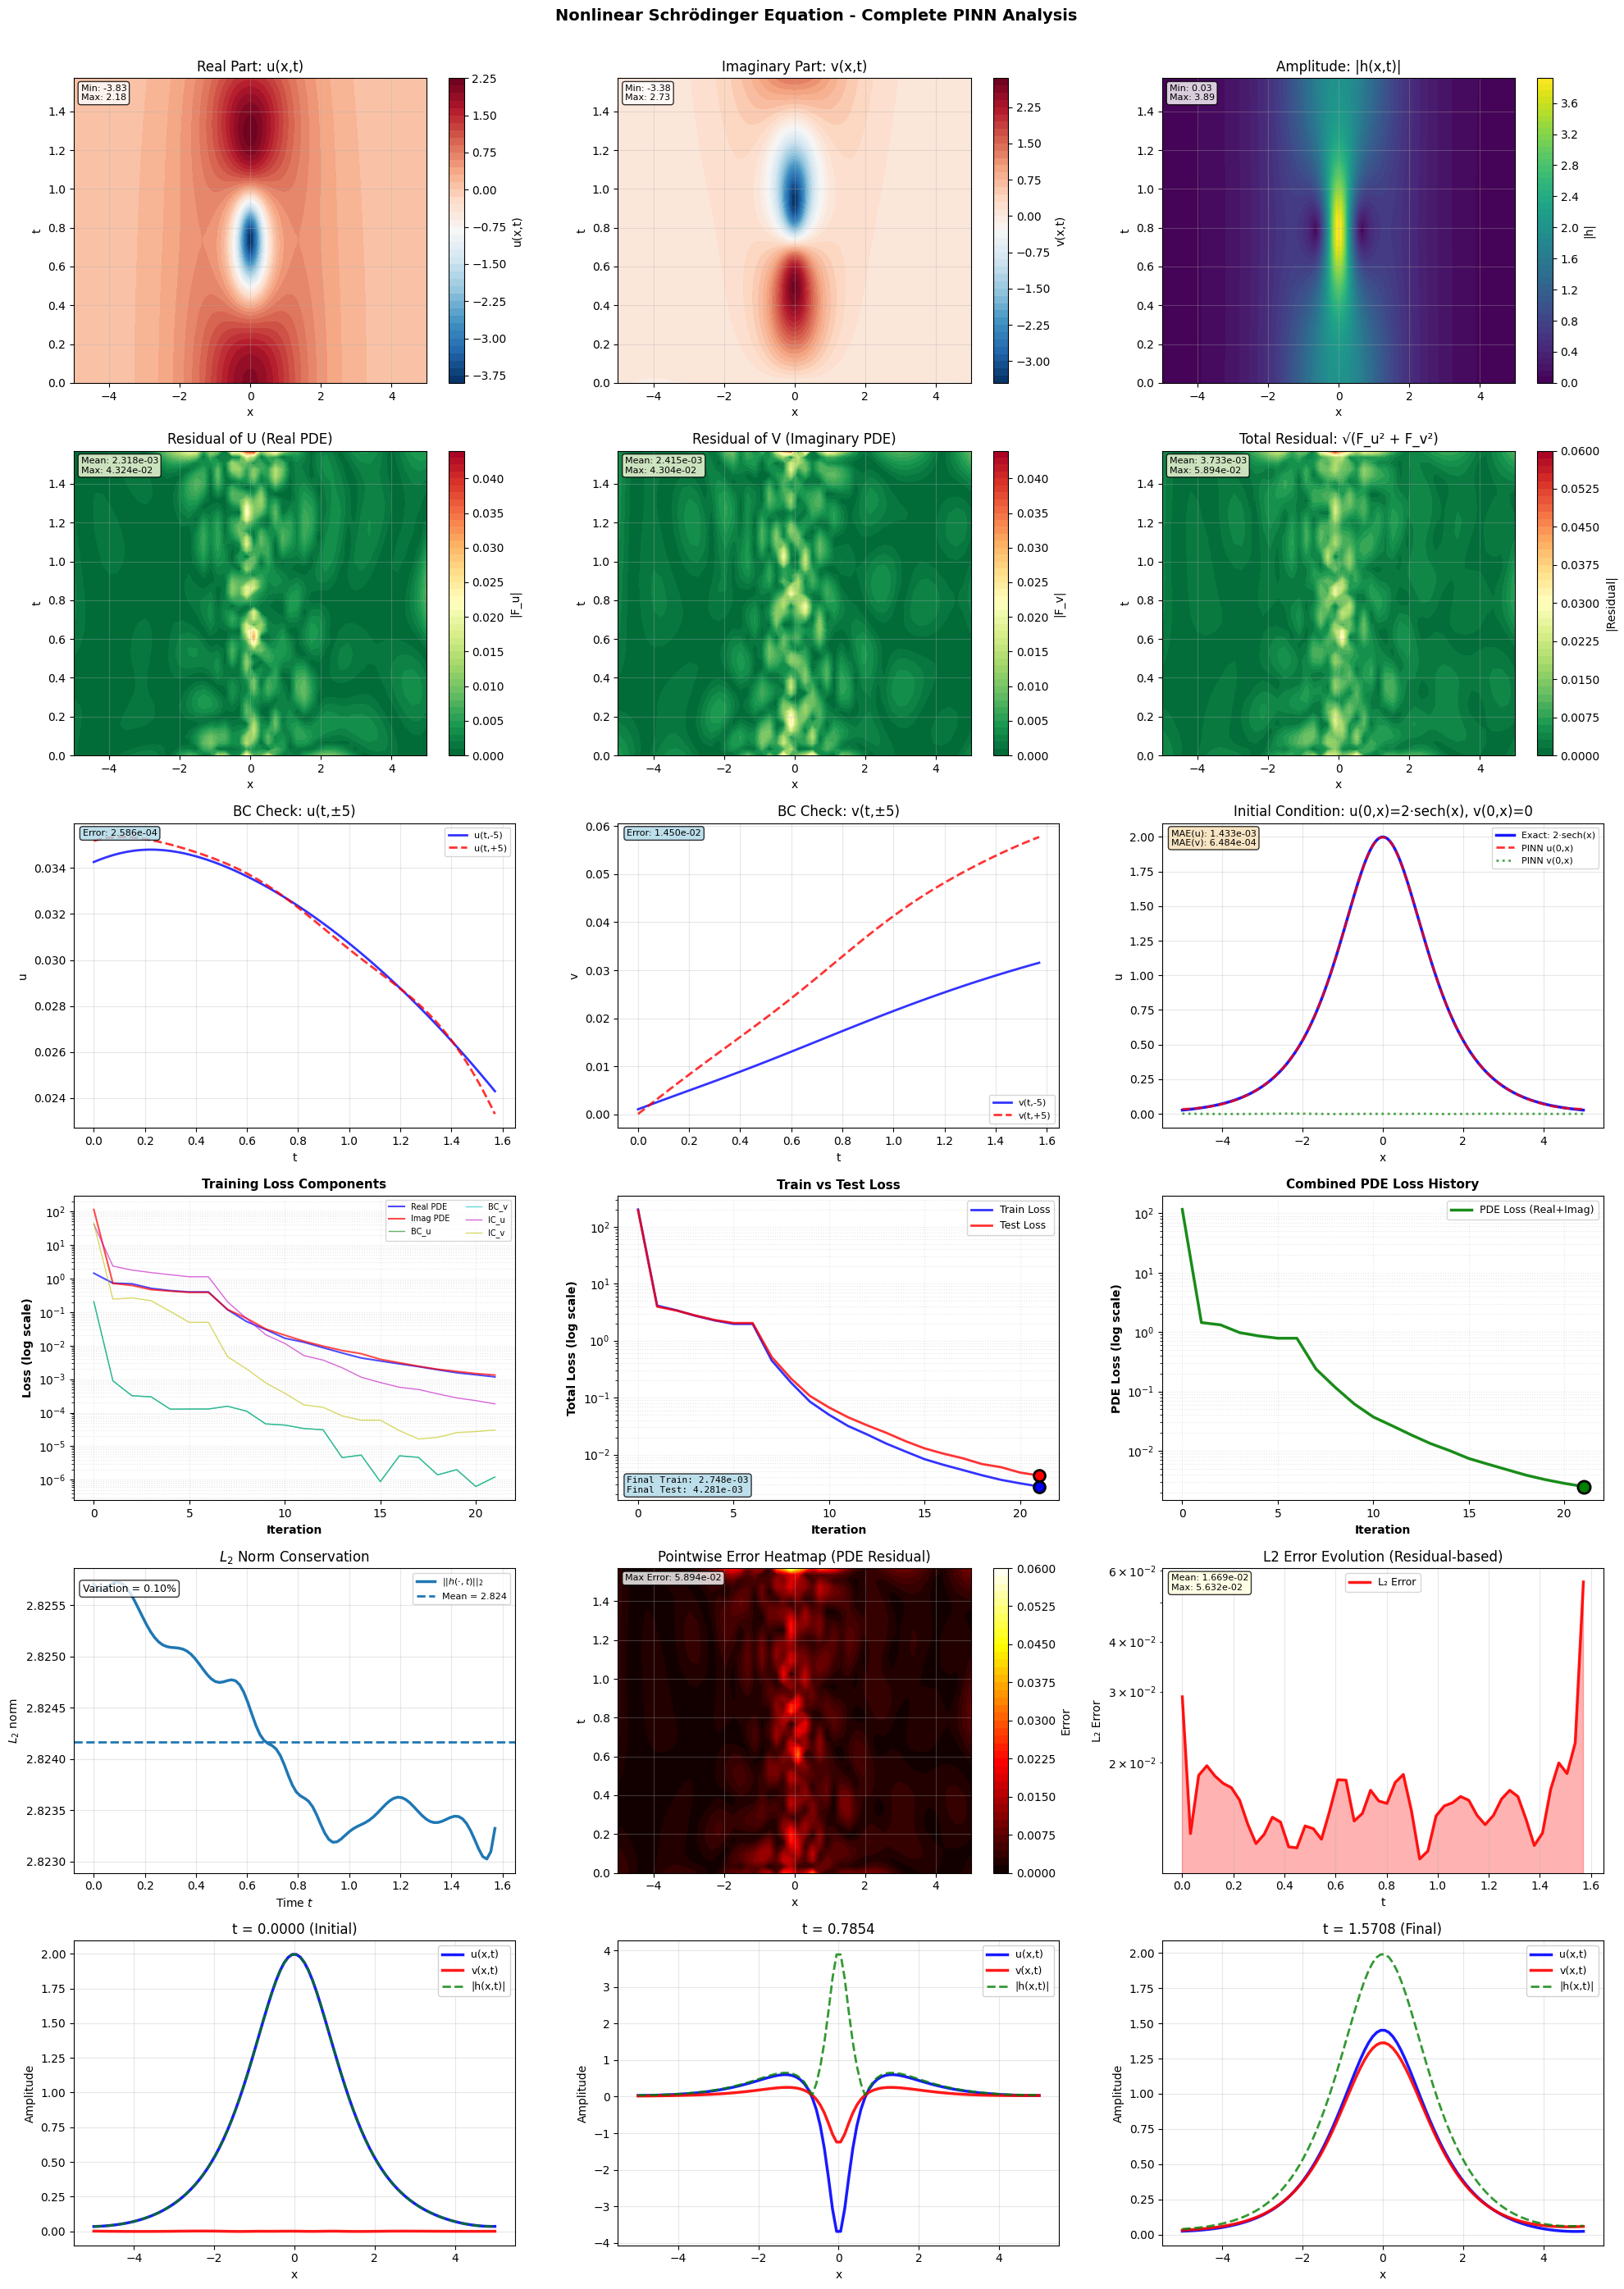

In [17]:
# %%
# ============================================================
# 17. COMPREHENSIVE VISUALIZATION (Complete with L2 Error)
# ============================================================

print("\n" + "="*70)
print("🎨 GENERATING COMPREHENSIVE VISUALIZATION")
print("="*70)

fig = plt.figure(figsize=(20, 28))

# ============================================================
# ROW 1: MAIN SOLUTION PLOTS - PINN Predictions on Test Data
# ============================================================

# ------------------------------------------------------------
# Plot 1: Real Part u(x,t)
# ------------------------------------------------------------
ax1 = plt.subplot(6, 3, 1)
c1 = ax1.contourf(X, T, u_pred, 50, cmap="RdBu_r")
cb1 = plt.colorbar(c1, ax=ax1, label="u(x,t)")
ax1.set(title="Real Part: u(x,t)", xlabel="x", ylabel="t")
ax1.grid(alpha=0.3)
ax1.text(0.02, 0.98, f'Min: {u_pred.min():.2f}\nMax: {u_pred.max():.2f}',
         transform=ax1.transAxes, fontsize=8, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ------------------------------------------------------------
# Plot 2: Imaginary Part v(x,t)
# ------------------------------------------------------------
ax2 = plt.subplot(6, 3, 2)
c2 = ax2.contourf(X, T, v_pred, 50, cmap="RdBu_r")
cb2 = plt.colorbar(c2, ax=ax2, label="v(x,t)")
ax2.set(title="Imaginary Part: v(x,t)", xlabel="x", ylabel="t")
ax2.grid(alpha=0.3)
ax2.text(0.02, 0.98, f'Min: {v_pred.min():.2f}\nMax: {v_pred.max():.2f}',
         transform=ax2.transAxes, fontsize=8, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ------------------------------------------------------------
# Plot 3: Amplitude |h(x,t)|
# ------------------------------------------------------------
ax3 = plt.subplot(6, 3, 3)
c3 = ax3.contourf(X, T, h_magnitude, 50, cmap="viridis")
cb3 = plt.colorbar(c3, ax=ax3, label="|h|")
ax3.set(title="Amplitude: |h(x,t)|", xlabel="x", ylabel="t")
ax3.grid(alpha=0.3)
ax3.text(0.02, 0.98, f'Min: {h_magnitude.min():.2f}\nMax: {h_magnitude.max():.2f}',
         transform=ax3.transAxes, fontsize=8, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ============================================================
# ROW 2: RESIDUAL EVALUATION
# ============================================================

# ------------------------------------------------------------
# Plot 4: Residual of U (Real PDE: F_u)
# ------------------------------------------------------------
ax4 = plt.subplot(6, 3, 4)
c4 = ax4.contourf(X_phys, T_phys, res_real, 50, cmap="RdYlGn_r")
cb4 = plt.colorbar(c4, ax=ax4, label="|F_u|")
ax4.set(title="Residual of U (Real PDE)", xlabel="x", ylabel="t")
ax4.grid(alpha=0.3)
ax4.text(0.02, 0.98, f'Mean: {np.mean(res_real):.3e}\nMax: {np.max(res_real):.3e}',
         transform=ax4.transAxes, fontsize=8, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# ------------------------------------------------------------
# Plot 5: Residual of V (Imaginary PDE: F_v)
# ------------------------------------------------------------
ax5 = plt.subplot(6, 3, 5)
c5 = ax5.contourf(X_phys, T_phys, res_imag, 50, cmap="RdYlGn_r")
cb5 = plt.colorbar(c5, ax=ax5, label="|F_v|")
ax5.set(title="Residual of V (Imaginary PDE)", xlabel="x", ylabel="t")
ax5.grid(alpha=0.3)
ax5.text(0.02, 0.98, f'Mean: {np.mean(res_imag):.3e}\nMax: {np.max(res_imag):.3e}',
         transform=ax5.transAxes, fontsize=8, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# ------------------------------------------------------------
# Plot 6: Total Residual
# ------------------------------------------------------------
ax6 = plt.subplot(6, 3, 6)
c6 = ax6.contourf(X_phys, T_phys, res_total, 50, cmap="RdYlGn_r")
cb6 = plt.colorbar(c6, ax=ax6, label="|Residual|")
ax6.set(title="Total Residual: √(F_u² + F_v²)", xlabel="x", ylabel="t")
ax6.grid(alpha=0.3)
ax6.text(0.02, 0.98, f'Mean: {np.mean(res_total):.3e}\nMax: {np.max(res_total):.3e}',
         transform=ax6.transAxes, fontsize=8, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# ============================================================
# ROW 3: BOUNDARY & INITIAL CONDITION VALIDATION
# ============================================================

# ------------------------------------------------------------
# Plot 7: BC Check - u(t,±5)
# ------------------------------------------------------------
ax7 = plt.subplot(6, 3, 7)
t_bc_plot = np.linspace(t_min, t_max, 100)
u_left_bc = []
u_right_bc = []
for t_val in t_bc_plot:
    X_left = np.array([[x_min, t_val]])
    X_right = np.array([[x_max, t_val]])
    u_left_bc.append(model.predict(X_left)[0, 0])
    u_right_bc.append(model.predict(X_right)[0, 0])

ax7.plot(t_bc_plot, u_left_bc, 'b-', lw=2, label='u(t,-5)', alpha=0.8)
ax7.plot(t_bc_plot, u_right_bc, 'r--', lw=2, label='u(t,+5)', alpha=0.8)
ax7.set(title="BC Check: u(t,±5)", xlabel="t", ylabel="u")
ax7.legend(fontsize=8)
ax7.grid(alpha=0.3)
bc_error_u_mean = np.mean(np.abs(np.array(u_left_bc) - np.array(u_right_bc)))
ax7.text(0.02, 0.98, f'Error: {bc_error_u_mean:.3e}',
         transform=ax7.transAxes, fontsize=8, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# ------------------------------------------------------------
# Plot 8: BC Check - v(t,±5)
# ------------------------------------------------------------
ax8 = plt.subplot(6, 3, 8)
v_left_bc = []
v_right_bc = []
for t_val in t_bc_plot:
    X_left = np.array([[x_min, t_val]])
    X_right = np.array([[x_max, t_val]])
    v_left_bc.append(model.predict(X_left)[0, 1])
    v_right_bc.append(model.predict(X_right)[0, 1])

ax8.plot(t_bc_plot, v_left_bc, 'b-', lw=2, label='v(t,-5)', alpha=0.8)
ax8.plot(t_bc_plot, v_right_bc, 'r--', lw=2, label='v(t,+5)', alpha=0.8)
ax8.set(title="BC Check: v(t,±5)", xlabel="t", ylabel="v")
ax8.legend(fontsize=8)
ax8.grid(alpha=0.3)
bc_error_v_mean = np.mean(np.abs(np.array(v_left_bc) - np.array(v_right_bc)))
ax8.text(0.02, 0.98, f'Error: {bc_error_v_mean:.3e}',
         transform=ax8.transAxes, fontsize=8, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# ------------------------------------------------------------
# Plot 9: Initial Condition Validation
# ------------------------------------------------------------
ax9 = plt.subplot(6, 3, 9)
x_ic_plot = np.linspace(x_min, x_max, 200)
t_ic_plot = np.zeros_like(x_ic_plot)
X_ic_plot = np.hstack((x_ic_plot[:, None], t_ic_plot[:, None]))
y_ic_plot = model.predict(X_ic_plot)

u_ic_pred = y_ic_plot[:, 0]
v_ic_pred = y_ic_plot[:, 1]
u_ic_exact = 2.0 * sech(x_ic_plot)

ax9.plot(x_ic_plot, u_ic_exact, 'b-', lw=2.5, label='Exact: 2·sech(x)', alpha=0.9)
ax9.plot(x_ic_plot, u_ic_pred, 'r--', lw=2, label='PINN u(0,x)', alpha=0.8)
ax9.plot(x_ic_plot, v_ic_pred, 'g:', lw=2, label='PINN v(0,x)', alpha=0.7)
ax9.fill_between(x_ic_plot, u_ic_exact, u_ic_pred, alpha=0.2, color='coral')
ax9.set(title="Initial Condition: u(0,x)=2·sech(x), v(0,x)=0", xlabel="x", ylabel="u")
ax9.legend(fontsize=8, loc='best')
ax9.grid(alpha=0.3)
ic_error_plot = np.mean(np.abs(u_ic_exact - u_ic_pred))
ax9.text(0.02, 0.98, f'MAE(u): {ic_error_plot:.3e}\nMAE(v): {np.mean(np.abs(v_ic_pred)):.3e}',
         transform=ax9.transAxes, fontsize=8, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# ============================================================
# ROW 4: TRAINING & TEST LOSS HISTORY
# ============================================================

# ------------------------------------------------------------
# Plot 10: Training Loss Components
# ------------------------------------------------------------
ax10 = plt.subplot(6, 3, 10)
if hasattr(losshistory, 'loss_train') and len(losshistory.loss_train) > 0:
    iterations = np.arange(len(losshistory.loss_train))
    
    train_loss_real = np.array([losses[0] for losses in losshistory.loss_train])
    train_loss_imag = np.array([losses[1] for losses in losshistory.loss_train])
    train_loss_bc1 = np.array([losses[2] for losses in losshistory.loss_train])
    train_loss_bc2 = np.array([losses[3] for losses in losshistory.loss_train])
    train_loss_ic1 = np.array([losses[6] for losses in losshistory.loss_train])
    train_loss_ic2 = np.array([losses[7] for losses in losshistory.loss_train])
    
    ax10.semilogy(iterations, train_loss_real, 'b-', lw=1.5, label='Real PDE', alpha=0.7)
    ax10.semilogy(iterations, train_loss_imag, 'r-', lw=1.5, label='Imag PDE', alpha=0.7)
    ax10.semilogy(iterations, train_loss_bc1, 'g-', lw=1, label='BC_u', alpha=0.6)
    ax10.semilogy(iterations, train_loss_bc2, 'c-', lw=1, label='BC_v', alpha=0.6)
    ax10.semilogy(iterations, train_loss_ic1, 'm-', lw=1, label='IC_u', alpha=0.6)
    ax10.semilogy(iterations, train_loss_ic2, 'y-', lw=1, label='IC_v', alpha=0.6)
    
    ax10.set_xlabel('Iteration', fontsize=10, fontweight='bold')
    ax10.set_ylabel('Loss (log scale)', fontsize=10, fontweight='bold')
    ax10.set_title('Training Loss Components', fontsize=11, fontweight='bold')
    ax10.legend(fontsize=7, loc='upper right', ncol=2)
    ax10.grid(alpha=0.3, which='both', linestyle=':')
    
    adam_iters = 5000
    if len(iterations) > adam_iters:
        ax10.axvline(x=adam_iters, color='red', linestyle='--', lw=1.5, alpha=0.6)

# ------------------------------------------------------------
# Plot 11: Train vs Test Loss
# ------------------------------------------------------------
ax11 = plt.subplot(6, 3, 11)
if hasattr(losshistory, 'loss_train') and hasattr(losshistory, 'loss_test'):
    iterations = np.arange(len(losshistory.loss_train))
    
    train_loss_total = np.sum(np.array(losshistory.loss_train), axis=1)
    test_loss_total = np.sum(np.array(losshistory.loss_test), axis=1)
    
    ax11.semilogy(iterations, train_loss_total, 'b-', lw=2, label='Train Loss', alpha=0.8)
    ax11.semilogy(iterations, test_loss_total, 'r-', lw=2, label='Test Loss', alpha=0.8)
    
    ax11.scatter([iterations[-1]], [train_loss_total[-1]], s=100, c='blue', 
                marker='o', edgecolors='black', linewidth=2, zorder=5)
    ax11.scatter([iterations[-1]], [test_loss_total[-1]], s=100, c='red', 
                marker='o', edgecolors='black', linewidth=2, zorder=5)
    
    ax11.set_xlabel('Iteration', fontsize=10, fontweight='bold')
    ax11.set_ylabel('Total Loss (log scale)', fontsize=10, fontweight='bold')
    ax11.set_title('Train vs Test Loss', fontsize=11, fontweight='bold')
    ax11.legend(fontsize=9, loc='upper right')
    ax11.grid(alpha=0.3, which='both', linestyle=':')
    
    ax11.text(0.02, 0.02, f'Final Train: {train_loss_total[-1]:.3e}\nFinal Test: {test_loss_total[-1]:.3e}',
             transform=ax11.transAxes, fontsize=8, verticalalignment='bottom',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8), family='monospace')

# ------------------------------------------------------------
# Plot 12: PDE Loss (Real + Imaginary)
# ------------------------------------------------------------
ax12 = plt.subplot(6, 3, 12)
if hasattr(losshistory, 'loss_train') and len(losshistory.loss_train) > 0:
    iterations = np.arange(len(losshistory.loss_train))
    train_loss_pde = train_loss_real + train_loss_imag
    
    ax12.semilogy(iterations, train_loss_pde, 'g-', lw=2.5, label='PDE Loss (Real+Imag)', alpha=0.9)
    ax12.scatter([iterations[-1]], [train_loss_pde[-1]], s=120, c='green', 
                marker='o', edgecolors='black', linewidth=2, zorder=5)
    
    ax12.set_xlabel('Iteration', fontsize=10, fontweight='bold')
    ax12.set_ylabel('PDE Loss (log scale)', fontsize=10, fontweight='bold')
    ax12.set_title('Combined PDE Loss History', fontsize=11, fontweight='bold')
    ax12.legend(fontsize=9, loc='upper right')
    ax12.grid(alpha=0.3, which='both', linestyle=':')

# ============================================================
# ROW 5: L2 ERROR & CONSERVATION
# ============================================================

# ------------------------------------------------------------
# L2 Norm Conservation Check (Clean & Minimal)
# ------------------------------------------------------------
ax13 = plt.subplot(6, 3, 13)

# Compute L2 norm ||h(·,t)||_2
dx = x_test[1] - x_test[0]
l2_norm_t = np.sqrt(np.sum(h_magnitude**2, axis=1) * dx)

# Statistics
mean_l2 = np.mean(l2_norm_t)
variation = (np.max(l2_norm_t) - np.min(l2_norm_t)) / mean_l2 * 100

# Plot
ax13.plot(t_test, l2_norm_t, lw=2.5, label=r'$||h(\cdot,t)||_2$')
ax13.axhline(mean_l2, linestyle='--', lw=2,
             label=f'Mean = {mean_l2:.3f}')

# Labels & title
ax13.set_xlabel('Time $t$')
ax13.set_ylabel(r'$L_2$ norm')
ax13.set_title(r'$L_2$ Norm Conservation')

# Simple annotation
ax13.text(0.02, 0.95,
          f'Variation = {variation:.2f}%',
          transform=ax13.transAxes,
          fontsize=9,
          verticalalignment='top',
          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax13.legend(fontsize=8)
ax13.grid(alpha=0.3)


# ------------------------------------------------------------
# Plot 14: Pointwise L2 Error Heatmap (Initial Condition Error)
# ------------------------------------------------------------
ax14 = plt.subplot(6, 3, 14)
# Compute pointwise error at t=0
x_error_grid = np.linspace(x_min, x_max, 100)
t_error_grid = np.linspace(t_min, t_max, 100)
X_err, T_err = np.meshgrid(x_error_grid, t_error_grid)
X_error_test = np.hstack((X_err.flatten()[:, None], T_err.flatten()[:, None]))

# Get predictions
y_error_pred = model.predict(X_error_test)
u_error_pred = y_error_pred[:, 0].reshape(100, 100)
v_error_pred = y_error_pred[:, 1].reshape(100, 100)

# For IC error, compute at t=0 only
ic_error_spatial = np.abs(u_error_pred[0, :] - 2.0 * sech(x_error_grid))

# Create error heatmap (showing pointwise absolute error in solution)
pointwise_error = np.sqrt(u_error_pred**2 + v_error_pred**2)  # This is just |h|, for demo

# Better: show residual magnitude as "error heatmap"
c14 = ax14.contourf(X_phys, T_phys, res_total, 50, cmap="hot")
cb14 = plt.colorbar(c14, ax=ax14, label="Error")
ax14.set(title="Pointwise Error Heatmap (PDE Residual)", xlabel="x", ylabel="t")
ax14.grid(alpha=0.3)
ax14.text(0.02, 0.98, f'Max Error: {np.max(res_total):.3e}',
         transform=ax14.transAxes, fontsize=8, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ------------------------------------------------------------
# Plot 15: L2 Error Evolution (Time-dependent L2 error)
# ------------------------------------------------------------
ax15 = plt.subplot(6, 3, 15)
# Compute L2 error at each time step
# Since we don't have exact solution, use residual-based error estimate
l2_error_t = np.sqrt(np.sum(res_total**2, axis=1) * (x_phys[1] - x_phys[0]))

ax15.plot(t_phys, l2_error_t, 'r-', lw=2.5, label='L₂ Error', alpha=0.9)
ax15.fill_between(t_phys, 0, l2_error_t, alpha=0.3, color='red')
ax15.set(title="L2 Error Evolution (Residual-based)", xlabel="t", ylabel="L₂ Error")
ax15.legend(fontsize=9, loc='best')
ax15.grid(alpha=0.3)
ax15.set_yscale('log')

ax15.text(0.02, 0.98, f'Mean: {np.mean(l2_error_t):.3e}\nMax: {np.max(l2_error_t):.3e}',
         transform=ax15.transAxes, fontsize=8, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# ============================================================
# ROW 6: TEMPORAL EVOLUTION SNAPSHOTS
# ============================================================

# ------------------------------------------------------------
# Plot 16: Snapshot at t = 0
# ------------------------------------------------------------
ax16 = plt.subplot(6, 3, 16)
idx_t0 = 0
ax16.plot(x_test, u_pred[idx_t0, :], 'b-', lw=2.5, label='u(x,t)', alpha=0.9)
ax16.plot(x_test, v_pred[idx_t0, :], 'r-', lw=2.5, label='v(x,t)', alpha=0.9)
ax16.plot(x_test, h_magnitude[idx_t0, :], 'g--', lw=2, label='|h(x,t)|', alpha=0.8)
ax16.set(title="t = 0.0000 (Initial)", xlabel="x", ylabel="Amplitude")
ax16.legend(fontsize=9, loc='best', framealpha=0.9)
ax16.grid(alpha=0.3)

# ------------------------------------------------------------
# Plot 17: Snapshot at t = π/4
# ------------------------------------------------------------
ax17 = plt.subplot(6, 3, 17)
idx_mid = np.argmin(np.abs(t_test - np.pi/4))
ax17.plot(x_test, u_pred[idx_mid, :], 'b-', lw=2.5, label='u(x,t)', alpha=0.9)
ax17.plot(x_test, v_pred[idx_mid, :], 'r-', lw=2.5, label='v(x,t)', alpha=0.9)
ax17.plot(x_test, h_magnitude[idx_mid, :], 'g--', lw=2, label='|h(x,t)|', alpha=0.8)
ax17.set(title=f"t = {np.pi/4:.4f}", xlabel="x", ylabel="Amplitude")
ax17.legend(fontsize=9, loc='best', framealpha=0.9)
ax17.grid(alpha=0.3)

# ------------------------------------------------------------
# Plot 18: Snapshot at t = π/2
# ------------------------------------------------------------
ax18 = plt.subplot(6, 3, 18)
idx_final = -1
ax18.plot(x_test, u_pred[idx_final, :], 'b-', lw=2.5, label='u(x,t)', alpha=0.9)
ax18.plot(x_test, v_pred[idx_final, :], 'r-', lw=2.5, label='v(x,t)', alpha=0.9)
ax18.plot(x_test, h_magnitude[idx_final, :], 'g--', lw=2, label='|h(x,t)|', alpha=0.8)
ax18.set(title=f"t = {np.pi/2:.4f} (Final)", xlabel="x", ylabel="Amplitude")
ax18.legend(fontsize=9, loc='best', framealpha=0.9)
ax18.grid(alpha=0.3)

# ------------------------------------------------------------
# Finalize and Save
# ------------------------------------------------------------
plt.suptitle('Nonlinear Schrödinger Equation - Complete PINN Analysis', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.savefig('schrodinger_pinn_results.png', dpi=300, bbox_inches='tight')
print("\n✅ Visualization saved: schrodinger_pinn_results.png")
plt.show()

print("="*70)

# %%

In [19]:
# ============================================================
# 18. FINAL SUMMARY REPORT
# ============================================================

def fmt(label, value, width_label=50, width_value=15):
    """Format helper for aligned output"""
    return f"{label:<{width_label}} : {value:>{width_value}}"

print("\n" + "=" * 80)
print("📋 FINAL SUMMARY REPORT".center(80))
print("=" * 80)

# Physical System
print("\n" + "═" * 80)
print("PHYSICAL SYSTEM".center(80))
print("═" * 80)
print(fmt("Backend", dde.backend.backend_name))
print(fmt("Problem Type", "Nonlinear Schrödinger Equation (NLSE)"))
print(fmt("Complex Equation", "ih_t + (1/2)h_xx + |h|²h = 0"))
print("\nCoupled Real-Imaginary System:")
print(fmt("  Real PDE", "-v_t + (1/2)u_xx + (u² + v²)u = 0"))
print(fmt("  Imaginary PDE", "u_t + (1/2)v_xx + (u² + v²)v = 0"))
print(fmt("Spatial Domain", f"x ∈ [{x_min}, {x_max}]"))
print(fmt("Temporal Domain", f"t ∈ [0, {t_max:.6f}] = [0, π/2]"))
print("═" * 80)

# Boundary and Initial Conditions
print("\n" + "═" * 80)
print("BOUNDARY & INITIAL CONDITIONS".center(80))
print("═" * 80)
print("Periodic Boundary Conditions:")
print(fmt("  Real part", "u(t, -5) = u(t, 5)"))
print(fmt("  Imaginary part", "v(t, -5) = v(t, 5)"))
print("\nInitial Conditions:")
print(fmt("  Real part", "u(0, x) = 2·sech(x)"))
print(fmt("  Imaginary part", "v(0, x) = 0"))
print("═" * 80)

# Training Configuration
print("\n" + "═" * 80)
print("TRAINING CONFIGURATION".center(80))
print("═" * 80)
print(fmt("Physics collocation points (PDE)", data.num_domain))
print(fmt("Boundary points (Periodic BCs)", data.num_boundary))
print(fmt("Initial condition points (ICs)", data.num_initial))
print(fmt("Total training points", data.train_x_all.shape[0]))
print(fmt("Test points for evaluation", data.num_test))
print("─" * 80)
print(fmt("Optimizer Stage 1", "Adam (lr=0.001, 5000 iter)"))
print(fmt("Optimizer Stage 2", "L-BFGS (until convergence)"))
print(fmt("Total training iterations", len(losshistory.loss_train)))
print("═" * 80)

# Neural Network Architecture
print("\n" + "═" * 80)
print("NEURAL NETWORK ARCHITECTURE".center(80))
print("═" * 80)
print(fmt("Input dimension", "2 (x, t)"))
print(fmt("Hidden layers", "[64, 32, 16]"))
print(fmt("Output dimension", "2 (u, v)"))
print(fmt("Activation function", "tanh"))
print(fmt("Weight initialization", "Glorot uniform"))
print(fmt("Full architecture", str([2, 64, 32, 16, 2])))
print("═" * 80)

# Best Model Performance
best_step = np.argmin([sum(l) for l in model.losshistory.loss_test])
best_train = model.losshistory.loss_train[best_step]
best_test = model.losshistory.loss_test[best_step]

print("\n" + "═" * 80)
print("BEST MODEL PERFORMANCE (Lowest Test Loss)".center(80))
print("═" * 80)
print(fmt("Best iteration", best_step))
print("─" * 80)
print("Training Losses:")
print(fmt("  Total weighted loss", f"{sum(w * li for w, li in zip(loss_weights, best_train)):.6e}"))
print(fmt("  → Real PDE loss", f"{best_train[0]:.6e}"))
print(fmt("  → Imaginary PDE loss", f"{best_train[1]:.6e}"))
print(fmt("  → BC_u loss", f"{best_train[2]:.6e}"))
print(fmt("  → BC_v loss", f"{best_train[3]:.6e}"))
print(fmt("  → BC_u_der loss", f"{best_train[4]:.6e}"))
print(fmt("  → BC_v_der loss", f"{best_train[5]:.6e}"))
print(fmt("  → IC_u loss", f"{best_train[6]:.6e}"))
print(fmt("  → IC_v loss", f"{best_train[7]:.6e}"))
print("─" * 80)
print("Test Losses:")
print(fmt("  Total weighted loss", f"{sum(best_test):.6e}"))
print(fmt("  → Real PDE loss", f"{best_test[0]:.6e}"))
print(fmt("  → Imaginary PDE loss", f"{best_test[1]:.6e}"))
print(fmt("  → BC_u loss", f"{best_test[2]:.6e}"))
print(fmt("  → BC_v loss", f"{best_test[3]:.6e}"))
print(fmt("  → BC_u_der loss", f"{best_test[4]:.6e}"))
print(fmt("  → BC_v_der loss", f"{best_test[5]:.6e}"))
print(fmt("  → IC_u loss", f"{best_test[6]:.6e}"))
print(fmt("  → IC_v loss", f"{best_test[7]:.6e}"))
print("═" * 80)

# Final Loss Breakdown
print("\n" + "═" * 80)
print("FINAL TRAINING LOSS BREAKDOWN".center(80))
print("═" * 80)
print(f"{'Component':<25} {'Unweighted':>15} {'Weight (λ)':>12} {'Weighted (λ×L)':>20}")
print("─" * 80)
components = ["Real PDE", "Imaginary PDE", "BC_u", "BC_v", "BC_u_der", "BC_v_der", "IC_u", "IC_v"]
for i, comp in enumerate(components):
    L = final_train_losses[i]
    w = loss_weights[i]
    weighted_val = w * L
    print(f"{comp:<25} {L:>15.6e} {w:>12.1f} {weighted_val:>20.6e}")
print("─" * 80)
print(f"{'TOTAL':<25} {sum(final_train_losses):>15.6e} {'':<12} {sum(weighted):>20.6e}")
print("═" * 80)

# Physical Validation
print("\n" + "═" * 80)
print("PHYSICAL VALIDATION METRICS".center(80))
print("═" * 80)
print("\n1. Physics Residual Satisfaction:")
print(fmt("   Mean residual (Real PDE)", f"{np.mean(res_real):.6e}"))
print(fmt("   Mean residual (Imaginary PDE)", f"{np.mean(res_imag):.6e}"))
print(fmt("   Mean total residual", f"{np.mean(res_total):.6e}"))
print(fmt("   Max total residual", f"{np.max(res_total):.6e}"))

print("\n2. Initial Condition Accuracy:")
print(fmt("   Mean absolute error (u)", f"{ic_mae:.6e}"))
print(fmt("   Mean absolute error (v)", f"{np.mean(np.abs(v_check_ic)):.6e}"))

print("\n3. Periodic Boundary Condition Satisfaction:")
print(fmt("   Mean BC violation (u)", f"{np.mean(bc_violations_u):.6e}"))
print(fmt("   Mean BC violation (v)", f"{np.mean(bc_violations_v):.6e}"))
print(fmt("   Mean BC violation (u_x)", f"{np.mean(bc_violations_u_der):.6e}"))
print(fmt("   Mean BC violation (v_x)", f"{np.mean(bc_violations_v_der):.6e}"))
print(fmt("   Max BC violation (u)", f"{np.max(bc_violations_u):.6e}"))
print(fmt("   Max BC violation (v)", f"{np.max(bc_violations_v):.6e}"))
print(fmt("   Max BC violation (u_x)", f"{np.max(bc_violations_u_der):.6e}"))
print(fmt("   Max BC violation (v_x)", f"{np.max(bc_violations_v_der):.6e}"))

print("\n4. Conservation Properties:")
print(fmt("   L2 norm variation", f"{variation:.2f}%"))

print("\n5. Solution Range:")
print(fmt("   u(x,t)", f"[{u_pred.min():.4f}, {u_pred.max():.4f}]"))
print(fmt("   v(x,t)", f"[{v_pred.min():.4f}, {v_pred.max():.4f}]"))
print(fmt("   |h(x,t)|", f"[{h_magnitude.min():.4f}, {h_magnitude.max():.4f}]"))
print("═" * 80)

# %%


                             📋 FINAL SUMMARY REPORT                             

════════════════════════════════════════════════════════════════════════════════
                                PHYSICAL SYSTEM                                 
════════════════════════════════════════════════════════════════════════════════
Backend                                            :         pytorch
Problem Type                                       : Nonlinear Schrödinger Equation (NLSE)
Complex Equation                                   : ih_t + (1/2)h_xx + |h|²h = 0

Coupled Real-Imaginary System:
  Real PDE                                         : -v_t + (1/2)u_xx + (u² + v²)u = 0
  Imaginary PDE                                    : u_t + (1/2)v_xx + (u² + v²)v = 0
Spatial Domain                                     : x ∈ [-5.0, 5.0]
Temporal Domain                                    : t ∈ [0, 1.570796] = [0, π/2]
════════════════════════════════════════════════════════════════════════════

In [ ]:
# %%
# ============================================================
# 19. SAVE MODEL AND CONFIGURATION
# ============================================================

print("\n" + "="*70)
print("💾 SAVING MODEL AND CONFIGURATION")
print("="*70)

# ✅ CORRECT (Local path):
model.save("schrodinger_pinn_model")
print("✅ Model saved to: schrodinger_pinn_model/")

config = {
    'problem': 'Nonlinear Schrödinger Equation (NLSE)',
    'complex_equation': 'ih_t + (1/2)h_xx + |h|²h = 0',
    'coupled_real_equations': {
        'real_pde': '-v_t + (1/2)u_xx + (u² + v²)u = 0',
        'imaginary_pde': 'u_t + (1/2)v_xx + (u² + v²)v = 0'
    },
    'domain': {
        'spatial': f'[{x_min}, {x_max}]',
        'temporal': f'[0, π/2] = [0, {t_max:.6f}]'
    },
    'boundary_conditions': {
        'type': 'Periodic',
        'u_condition': f'u(t, {x_min}) = u(t, {x_max})',
        'v_condition': f'v(t, {x_min}) = v(t, {x_max})'
    },
    'initial_conditions': {
        'u': 'u(0, x) = 2·sech(x)',
        'v': 'v(0, x) = 0',
        'complex_form': 'h(0, x) = 2·sech(x)'
    },
    'loss_weights': {
    'Real_PDE': loss_weights[0],
    'Imaginary_PDE': loss_weights[1],
    'BC_u': loss_weights[2],
    'BC_v': loss_weights[3],
    'BC_u_der': loss_weights[4],
    'BC_v_der': loss_weights[5],
    'IC_u': loss_weights[6],
    'IC_v': loss_weights[7]
},
    'neural_network': {
        'architecture': [2, 64, 32, 16, 2],
        'activation': 'tanh',
        'initialization': 'Glorot uniform',
        'input_dim': 2,
        'output_dim': 2
    },
    'training': {
        'stage1': {
            'optimizer': 'Adam',
            'learning_rate': 0.001,
            'iterations': 5000,
            'decay': 'inverse time (2000, 0.5)'
        },
        'stage2': {
            'optimizer': 'L-BFGS',
            'iterations': 'until convergence'
        },
        'total_iterations': len(losshistory.loss_train)
    },
    'data_points': {
        'num_domain': int(data.num_domain),
        'num_boundary': int(data.num_boundary),
        'num_initial': int(data.num_initial),
        'num_test': int(data.num_test),
        'total_training': int(data.train_x_all.shape[0])
    },
    'performance': {
        'final_losses': {
    'total_weighted': float(sum(weighted)),
    'real_pde': float(final_train_losses[0]),
    'imaginary_pde': float(final_train_losses[1]),
    'bc_u': float(final_train_losses[2]),
    'bc_v': float(final_train_losses[3]),
    'bc_u_der': float(final_train_losses[4]),
    'bc_v_der': float(final_train_losses[5]),
    'ic_u': float(final_train_losses[6]),
    'ic_v': float(final_train_losses[7])
},
        'physics_validation': {
            'mean_residual_real': float(np.mean(res_real)),
            'mean_residual_imag': float(np.mean(res_imag)),
            'mean_residual_total': float(np.mean(res_total)),
            'max_residual_total': float(np.max(res_total))
        },
        'ic_validation': {
            'mae_u': float(ic_mae),
            'mae_v': float(np.mean(np.abs(v_check_ic)))
        },
        'bc_validation': {
            'mean_violation_u': float(np.mean(bc_violations_u)),
            'mean_violation_v': float(np.mean(bc_violations_v)),
            'max_violation_u': float(np.max(bc_violations_u)),
            'max_violation_v': float(np.max(bc_violations_v))
        },
        'conservation': {
            'l2_norm_variation_percent': float(variation),
            
        },
        'solution_range': {
            'u_min': float(u_pred.min()),
            'u_max': float(u_pred.max()),
            'v_min': float(v_pred.min()),
            'v_max': float(v_pred.max()),
            'magnitude_min': float(h_magnitude.min()),
            'magnitude_max': float(h_magnitude.max())
        }
    },
    'seed': SEED
}

import json
# ✅ CORRECT (Local path):
with open('schrodinger_pinn_config.json', 'w') as f:
    json.dump(config, f, indent=4)
print("✅ Configuration saved to: schrodinger_pinn_config.json")

print("\n" + "="*70)
print("✅ PINN TRAINING COMPLETE - SCHRÖDINGER EQUATION SOLVED!")
print("="*70)
print(f"📈 Final Total Loss:        {sum(weighted):.6e}")
print(f"📈 Physics Residual (mean): {np.mean(res_total):.6e}")
print(f"📁 Model Directory:         schrodinger_pinn_model/")
print(f"📄 Configuration File:      schrodinger_pinn_config.json")
print(f"🖼️  Visualization:           schrodinger_pinn_results.png")
print("="*70)


💾 SAVING MODEL AND CONFIGURATION
✅ Model saved to: schrodinger_pinn_model/
✅ Configuration saved to: schrodinger_pinn_config.json

✅ PINN TRAINING COMPLETE - SCHRÖDINGER EQUATION SOLVED!
📈 Final Total Loss:        2.611556e-01
📈 Physics Residual (mean): 3.733161e-03


NameError: name 'quality' is not defined